# STUDENT MENTAL HEALTH REPORT



**This project explores a dataset on student mental health to identify potential patterns related to depression, anxiety, and panic attacks.**

**The goal of this analysis is to understand how mental health issues are related to factors such as gender, academic performance (CGPA), marital status, and whether students seek professional treatment.**

## Data Cleaning

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline     
sns.set(color_codes=True)

#Link to the dataset
[Student Mental health](https://www.kaggle.com/datasets/shariful07/student-mental-health)

In [2]:
df = pd.read_csv('Student Mental health.csv')
df.head(5)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [3]:
df.tail(5)

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No
100,18/07/2020 20:16:21,Male,20.0,Biomedical science,Year 2,3.00 - 3.49,No,No,No,No,No


### Dataset Overview

*The dataset contains survey responses from university students regarding their mental health.  
It includes variables such as gender, marital status, GPA, depression, anxiety, panic attacks, and whether the student have specialist treatment.*

In [4]:
df.dtypes

Timestamp                                           str
Choose your gender                                  str
Age                                             float64
What is your course?                                str
Your current year of Study                          str
What is your CGPA?                                  str
Marital status                                      str
Do you have Depression?                             str
Do you have Anxiety?                                str
Do you have Panic attack?                           str
Did you seek any specialist for a treatment?        str
dtype: object

In [5]:
df.shape

(101, 11)

In [6]:
df = df.drop(['Timestamp'], axis=1)
df.head(5)

,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [7]:
df = df.rename(columns = {"Choose your gender" : "Gender", "What is your course?" : "Course", "Your current year of Study" : "Year of study", "What is your CGPA?" : "CGPA", "Do you have Depression?" : "Depression", 
"Do you have Anxiety?" : "Anxiety", "Do you have Panic attack?" : "Panic attack", "Did you seek any specialist for a treatment?" : "Specialist treatment"})
df.head(5)

,Gender,Age,Course,Year of study,CGPA,Marital status,Depression,Anxiety,Panic attack,Specialist treatment
0,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [8]:
#Cheking null and empty cells
df.count()

Gender                  101
Age                     100
Course                  101
Year of study           101
CGPA                    101
Marital status          101
Depression              101
Anxiety                 101
Panic attack            101
Specialist treatment    101
dtype: int64

In [9]:
print(df.isnull().sum())

Gender                  0
Age                     1
Course                  0
Year of study           0
CGPA                    0
Marital status          0
Depression              0
Anxiety                 0
Panic attack            0
Specialist treatment    0
dtype: int64


In [10]:
df = df.dropna()
print(df.isnull().sum())

Gender                  0
Age                     0
Course                  0
Year of study           0
CGPA                    0
Marital status          0
Depression              0
Anxiety                 0
Panic attack            0
Specialist treatment    0
dtype: int64


In [11]:
df.count()

Gender                  100
Age                     100
Course                  100
Year of study           100
CGPA                    100
Marital status          100
Depression              100
Anxiety                 100
Panic attack            100
Specialist treatment    100
dtype: int64

In [12]:
df["Course"].unique()

<StringArray>
[            'Engineering',       'Islamic education',
                     'BIT',                    'Laws',
            'Mathemathics',        'Pendidikan islam',
                     'BCS',         'Human Resources',
                   'Irkhs',              'Psychology',
                   'KENMS',             'Accounting ',
                     'ENM',          'Marine science',
                     'KOE',         'Banking Studies',
 'Business Administration',                     'Law',
                  'KIRKHS',              'Usuluddin ',
                   'TAASL',                  'Engine',
                     'ALA',      'Biomedical science',
                     'koe',                  'Kirkhs',
                    'BENL',                    'Benl',
                      'IT',                     'CTS',
                   'engin',                   'Econs',
                    'MHSC',                  'Malcom',
                     'Kop',         'Human Sciences

***The "Course" column contained inconsistent text formatting (e.g., "koe", "Koe", "KOE"). To ensure accurate aggregation, the values were standardized before performing the analysis.***

In [14]:
df["Course"] = df["Course"].str.strip().str.lower()

In [15]:
df["Course"] = df["Course"].str.title()

In [16]:
df["Course"].unique()

<StringArray>
[            'Engineering',       'Islamic Education',
                     'Bit',                    'Laws',
            'Mathemathics',        'Pendidikan Islam',
                     'Bcs',         'Human Resources',
                   'Irkhs',              'Psychology',
                   'Kenms',              'Accounting',
                     'Enm',          'Marine Science',
                     'Koe',         'Banking Studies',
 'Business Administration',                     'Law',
                  'Kirkhs',               'Usuluddin',
                   'Taasl',                  'Engine',
                     'Ala',      'Biomedical Science',
                    'Benl',                      'It',
                     'Cts',                   'Engin',
                   'Econs',                    'Mhsc',
                  'Malcom',                     'Kop',
          'Human Sciences',           'Biotechnology',
           'Communication',         'Diploma Nursin

In [17]:
df_clean = df.copy()

## Exploratory Data Analysis

In [18]:
df_clean.describe()
df_clean["Gender"].value_counts()

Gender
Female    75
Male      25
Name: count, dtype: int64

In [19]:
mental_health_gender = df_clean.groupby("Gender")[["Depression", "Anxiety", "Panic attack"]].apply(
    lambda x: (x == "Yes").sum())

In [20]:
print (mental_health_gender)

        Depression  Anxiety  Panic attack
Gender                                   
Female          29       24            25
Male             6       10             8


In [33]:
#This shows the percentage of female and male students who experience each type of mental health problem.

mental_health_percent = df_clean.groupby("Gender")[["Depression", "Anxiety", "Panic attack"]].apply(
    lambda x: (x == "Yes").mean() * 100)
print(mental_health_percent.round(1))

        Depression  Anxiety  Panic attack
Gender                                   
Female        38.7     32.0          33.3
Male          24.0     40.0          32.0


***Although the absolute numbers suggest that female students report more mental health issues, this is largely influenced by the dataset composition (75% female respondents). 
When examining percentages within each gender group, the prevalence of depression, anxiety, and panic attacks appears relatively similar between male and female students.
Therefore, percentage-based comparisons provide a more accurate representation than absolute counts.***

## Data Visualization


Text(0, 0.5, 'Number of Students')

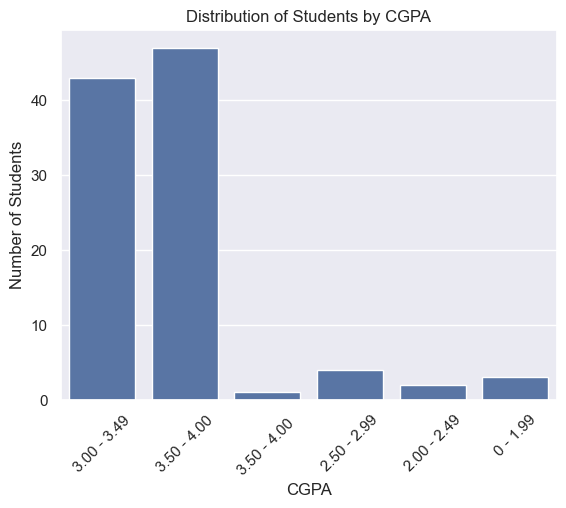

In [23]:
sns.countplot(x="CGPA", data=df_clean)
plt.xticks(rotation=45)
plt.title("Distribution of Students by CGPA")
plt.ylabel("Number of Students")

***The bar chart indicates that the majority of students achieve a high CGPA, with most values concentrated between 3.00 and 4.00.***

In [25]:
df_grouped = df_clean.groupby("Course")[["Depression", "Anxiety", "Panic attack"]].apply(
    lambda x: (x == "Yes").sum())

In [26]:
df_grouped.style.background_gradient(cmap="Reds")

,Depression,Anxiety,Panic attack
Course,,,
Accounting,0,0,0
Ala,1,0,1
Banking Studies,0,0,0
Bcs,5,6,5
Benl,2,1,0
Biomedical Science,0,0,0
Biotechnology,0,0,0
Bit,5,8,4
Business Administration,0,0,0


***Based on the table, the highest number of reported cases of depression, anxiety, and panic attacks is observed among students from the 
BCS (Bachelor of Computer Science),
BIT (Business Information Technology) and 
Engineering programs.***

Text(0, 0.5, 'Number of Students')

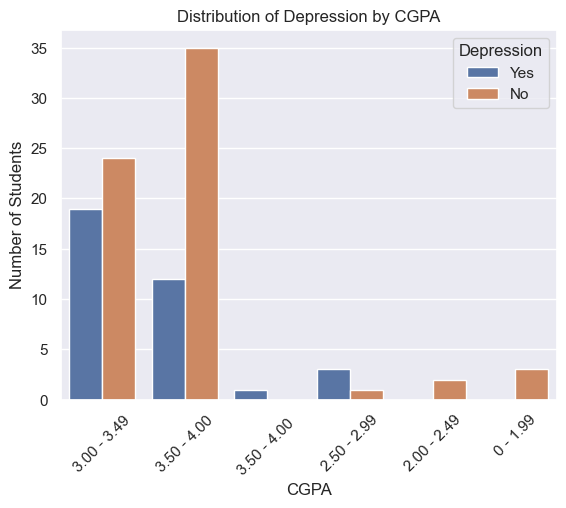

In [28]:
sns.countplot(x="CGPA", hue="Depression", data=df_clean)
plt.xticks(rotation=45)
plt.title("Distribution of Depression by CGPA")
plt.ylabel("Number of Students")

***This bar chart shows that students with higher grades (3.00–4.00) are more likely to experience mental health problems.***

Text(0, 0.5, 'Number of Students')

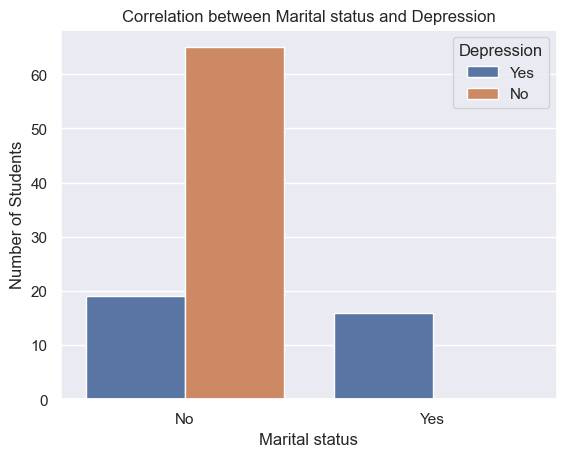

In [30]:
sns.countplot(x="Marital status", hue="Depression", data=df_clean)
plt.title("Correlation between Marital status and Depression")
plt.ylabel("Number of Students")

***The number of students reporting depression is similar among both married and unmarried students. 
However, it is notable that none of the married students reported not having depression.***

Text(0, 0.5, 'Number of Students')

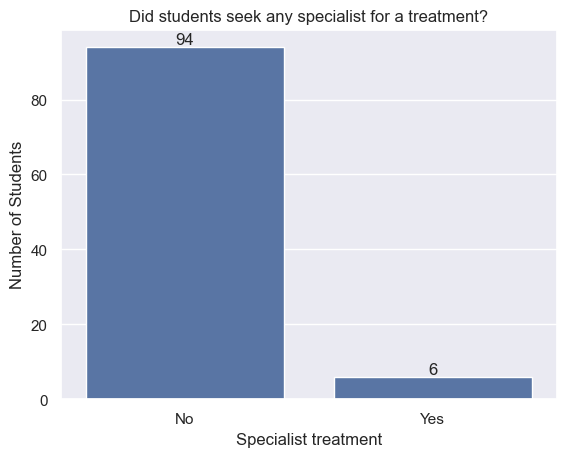

In [32]:
ax = sns.countplot(x="Specialist treatment", data=df_clean)
ax.bar_label(ax.containers[0])
plt.title("Did students seek any specialist for a treatment?")
plt.ylabel("Number of Students")


## Conclusion

*The analysis indicates that approximately one-third of the surveyed students report experiencing some form of mental health issue, including depression, anxiety, or panic attacks. These challenges appear across different demographic groups, including students with high academic performance, suggesting that mental health concerns are not limited to students who struggle academically.*

*Additionally, only a small proportion of students seek professional psychological treatment, which may indicate potential barriers such as stigma, limited awareness, lack of access to mental health services.*

*These findings highlight the importance of increased awareness and support systems for student mental health.*